In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')



In [2]:
df = pd.read_csv('data/stud.csv')
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
df.shape

(1000, 8)

In [4]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [7]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [8]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [9]:
dictionary = df.nunique().to_dict()
def unique_values(dictionary):
    for key,values in dictionary.items():
        if values < 10:
            
            print(f"Unique values in {key} are : {df[key].unique()}")
    print("\n")
unique_values(dictionary)

        

Unique values in gender are : ['female' 'male']
Unique values in race_ethnicity are : ['group B' 'group C' 'group A' 'group D' 'group E']
Unique values in parental_level_of_education are : ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Unique values in lunch are : ['standard' 'free/reduced']
Unique values in test_preparation_course are : ['none' 'completed']




In [10]:
numerical_cols = [feature for feature in df.columns if df[feature].dtype!='O']
categorical_cols = [feature for feature in df.columns if df[feature].dtype=='O']
print("{} Numerical columns  : {}".format(len(numerical_cols), numerical_cols))
print("\n{} Categorical columns  : {}".format(len(categorical_cols), categorical_cols)) 

3 Numerical columns  : ['math_score', 'reading_score', 'writing_score']

5 Categorical columns  : ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [11]:
df['Total_Marks'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['Average_Marks'] = df['Total_Marks']/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total_Marks,Average_Marks
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [12]:
math_full = df[df['math_score'] == 100]['Average_Marks'].count()
writing_full = df[df['writing_score'] == 100]['Average_Marks'].count()
reading_full = df[df['reading_score'] == 100]['Average_Marks'].count()
print("No. of Stud get full marks in maths",math_full)
print("No. of Stud get full marks in writing",writing_full)
print("No. of Stud get full marks in reading",reading_full)

No. of Stud get full marks in maths 7
No. of Stud get full marks in writing 14
No. of Stud get full marks in reading 17


In [13]:
readinG_less_20 = df[df['reading_score']<20]['Average_Marks'].count()
print("No. of Stud get less than 20 marks in reading",readinG_less_20)
math_less_20 = df[df['math_score']<20]['Average_Marks'].count()
print("No. of Stud get less than 20 marks in math",math_less_20)
writing_less_20 = df[df['writing_score']<20]['Average_Marks'].count()
print("No. of Stud get less than 20 marks in writing",writing_less_20)

No. of Stud get less than 20 marks in reading 1
No. of Stud get less than 20 marks in math 4
No. of Stud get less than 20 marks in writing 3


In [14]:
## Best performance in reading section
# Poor performance in maths section

In [15]:
# Histograms & KDE Plots

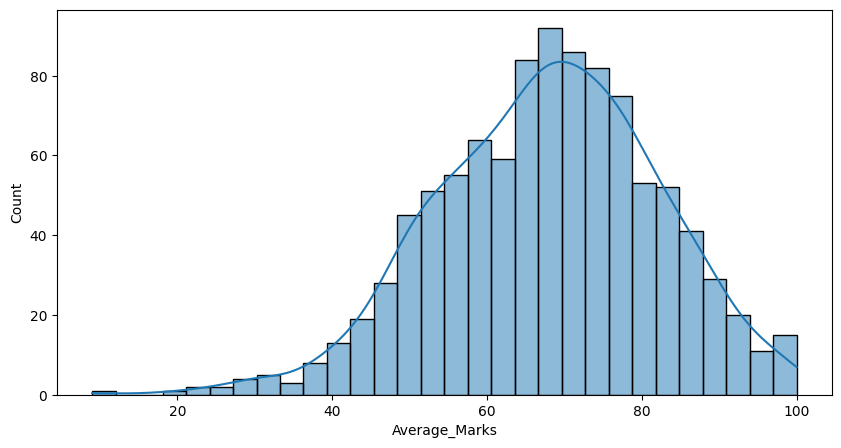

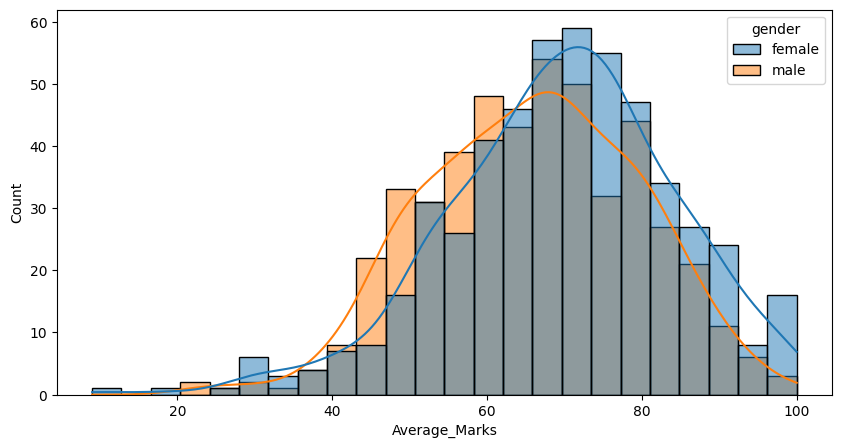

In [16]:
plt.subplots(figsize=(10,5))
sns.histplot(data=df,x='Average_Marks',bins=30,kde=True)
plt.subplots(figsize=(10,5))
sns.histplot(data=df,x='Average_Marks',kde=True,hue='gender')
plt.show()

In [17]:
# Female students have higher average marks

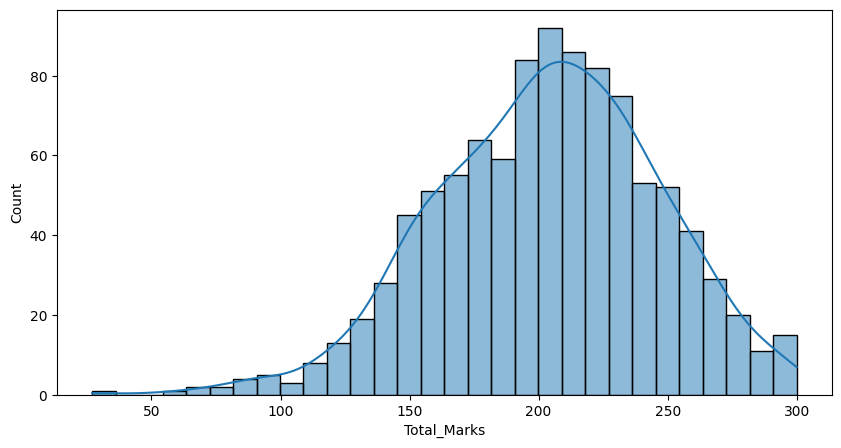

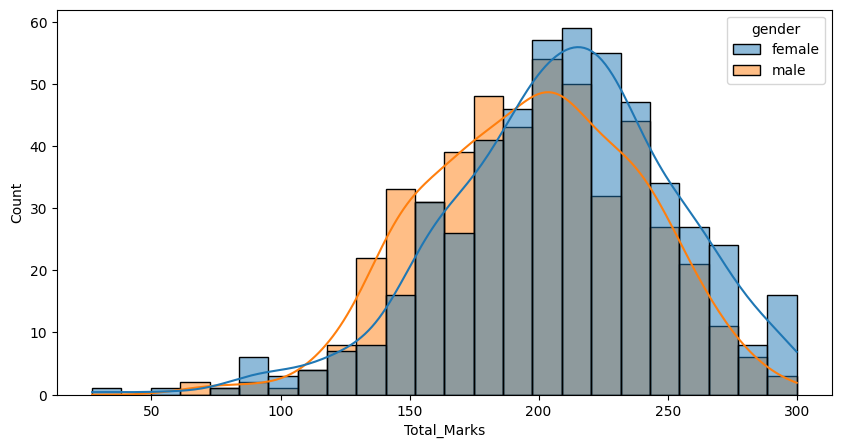

In [18]:
plt.subplots(figsize=(10,5))
sns.histplot(data=df,x='Total_Marks',bins=30,kde=True)
plt.subplots(figsize=(10,5))
sns.histplot(data=df,x='Total_Marks',kde=True,hue='gender')
plt.show()

In [19]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total_Marks,Average_Marks
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


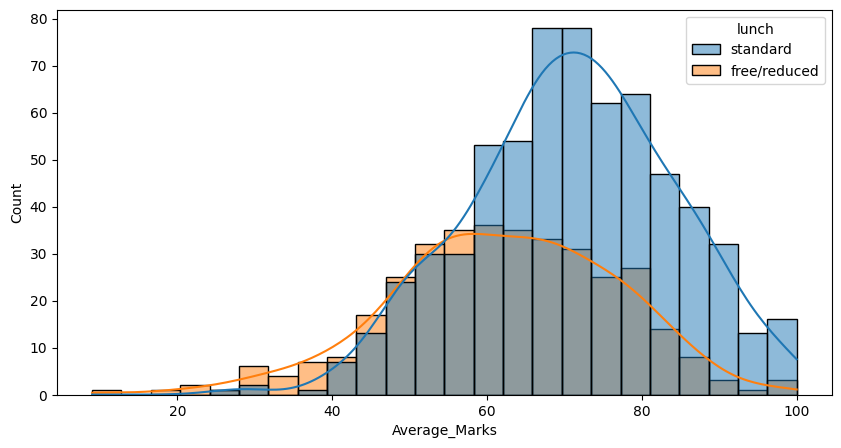

In [20]:
plt.subplots(figsize=(10,5))
sns.histplot(data=df,x='Average_Marks',kde=True,hue='lunch')
plt.show()

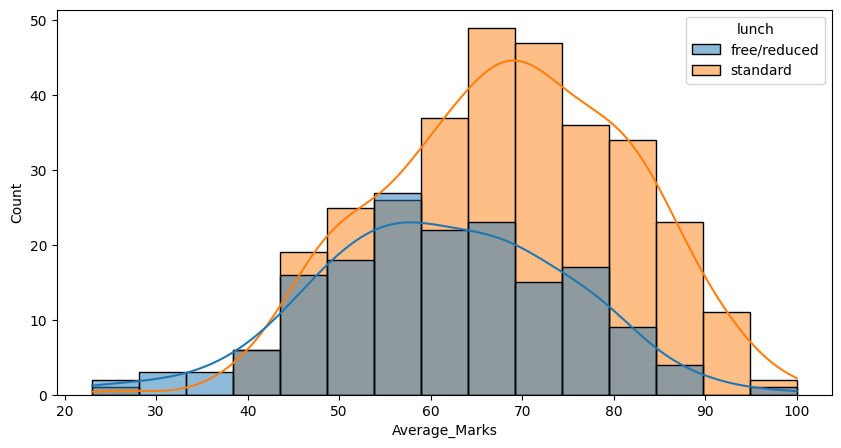

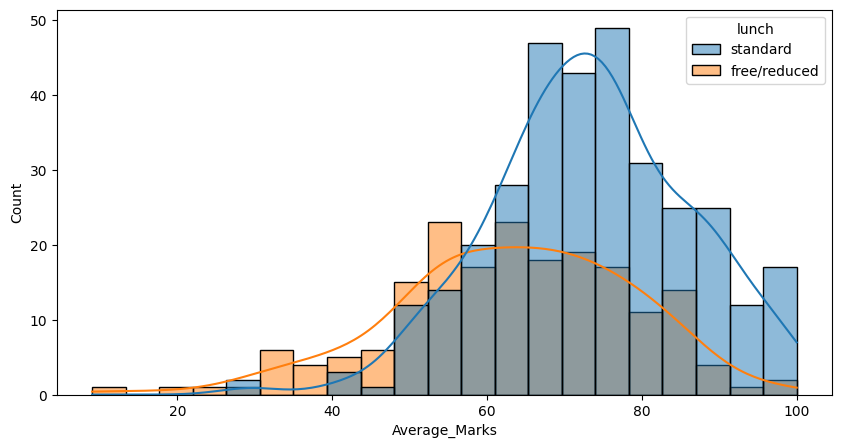

In [21]:
plt.subplots(figsize=(10,5))
sns.histplot(data=df[df.gender=='male'],x='Average_Marks',kde=True,hue='lunch')
plt.show()
plt.subplots(figsize=(10,5))
sns.histplot(data=df[df.gender=='female'],x='Average_Marks',kde=True,hue='lunch')
plt.show()

In [22]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total_Marks,Average_Marks
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


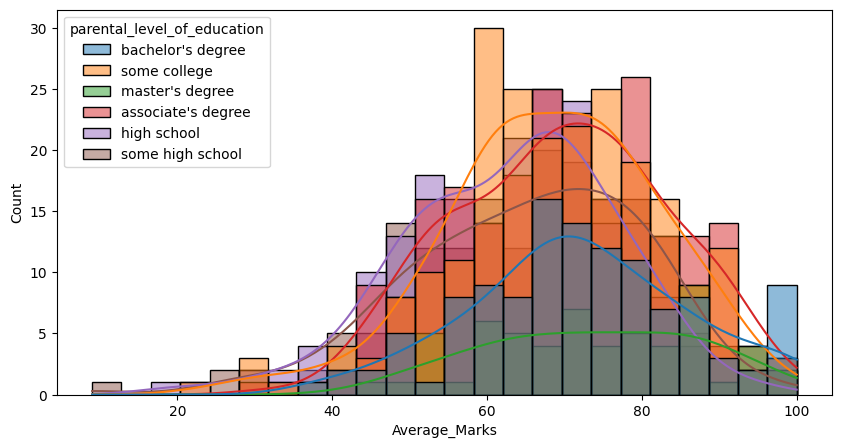

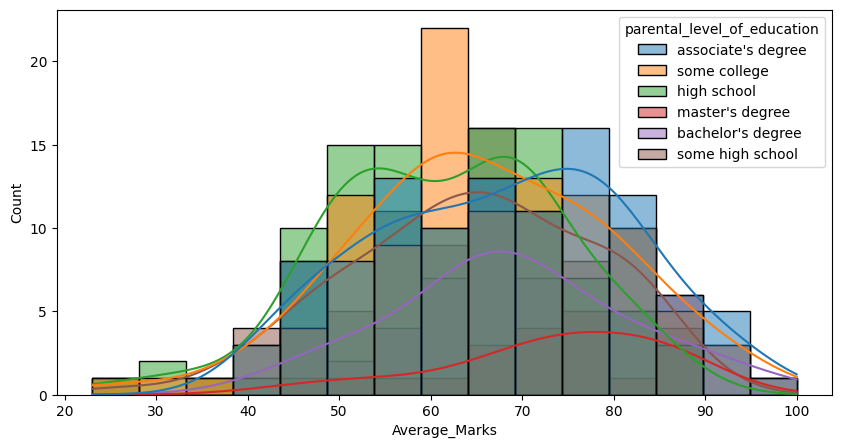

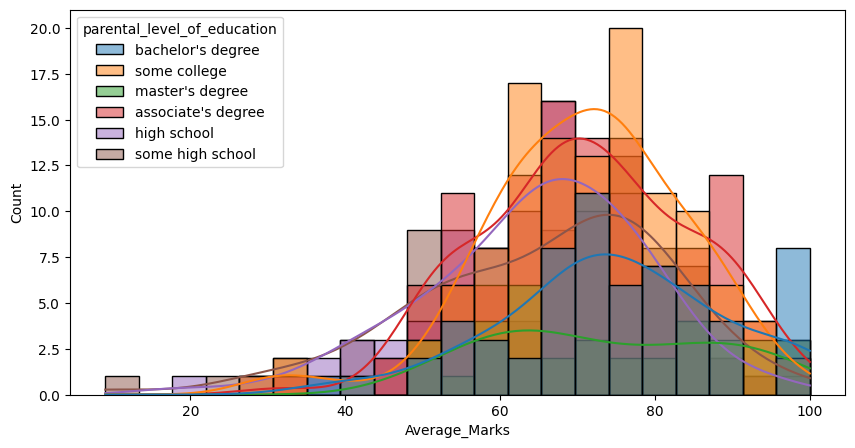

In [24]:
plt.subplots(figsize=(10,5))
sns.histplot(data=df,x='Average_Marks',kde=True,hue='parental_level_of_education')
plt.show()
plt.subplots(figsize=(10,5))
sns.histplot(data=df[df.gender=='male'],x='Average_Marks',kde=True,hue='parental_level_of_education')
plt.show()
plt.subplots(figsize=(10,5))
sns.histplot(data=df[df.gender=='female'],x='Average_Marks',kde=True,hue='parental_level_of_education')
plt.show()

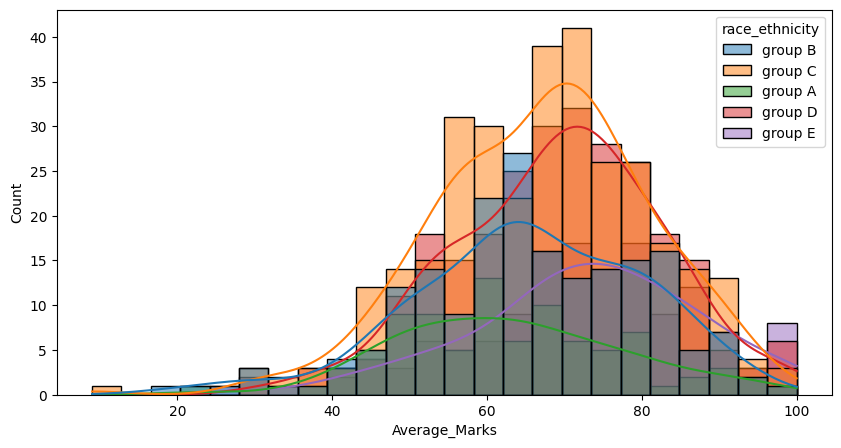

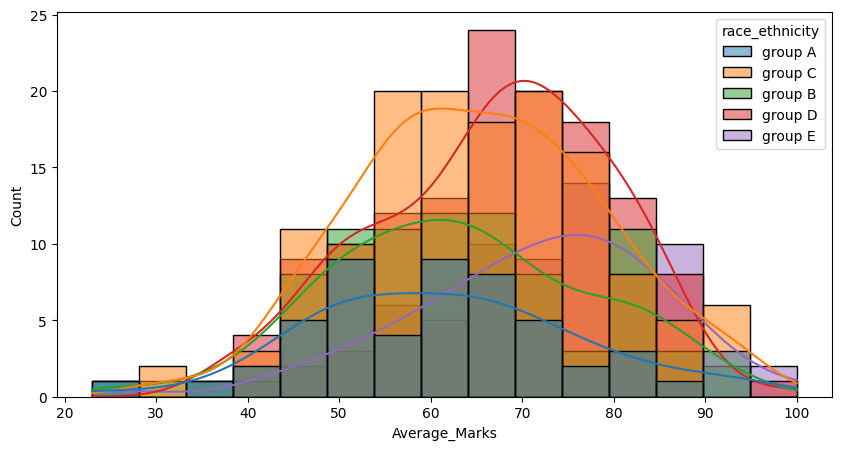

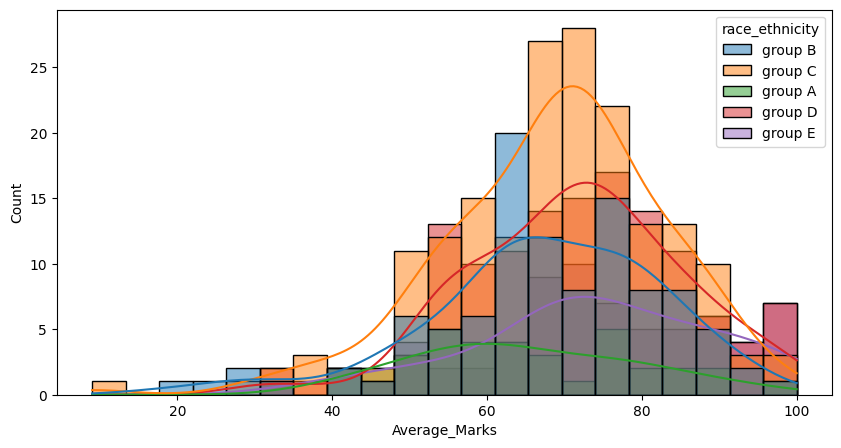

In [25]:
plt.subplots(figsize=(10,5))
sns.histplot(data=df,x='Average_Marks',kde=True,hue='race_ethnicity')
plt.show()
plt.subplots(figsize=(10,5))
sns.histplot(data=df[df.gender=='male'],x='Average_Marks',kde=True,hue='race_ethnicity')
plt.show()
plt.subplots(figsize=(10,5))
sns.histplot(data=df[df.gender=='female'],x='Average_Marks',kde=True,hue='race_ethnicity')
plt.show()

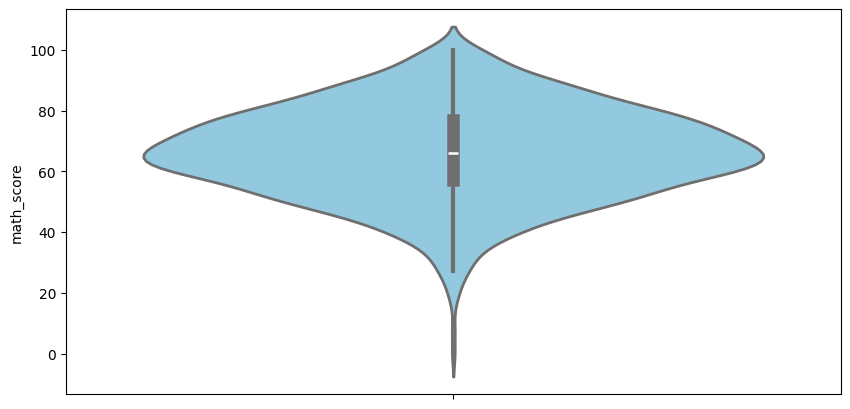

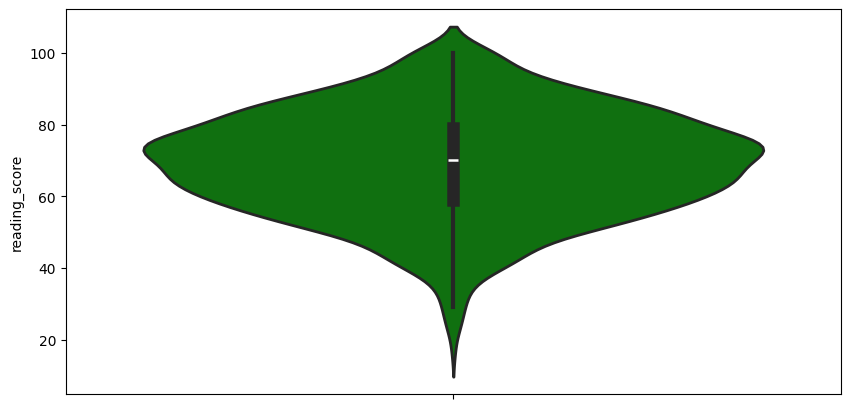

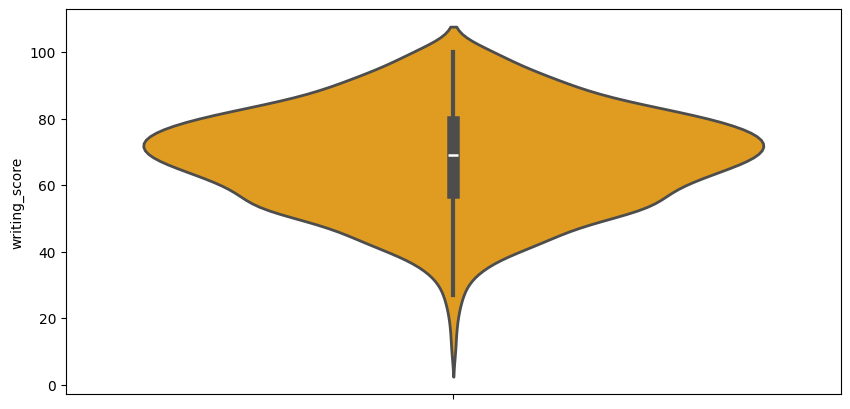

In [26]:
plt.subplots(figsize=(10,5))
sns.violinplot(y='math_score',data=df,color='skyblue',linewidth=2)
plt.show()
plt.subplots(figsize=(10,5))
sns.violinplot(y='reading_score',data=df,color='green',linewidth=2)
plt.show()
plt.subplots(figsize=(10,5))
sns.violinplot(y='writing_score',data=df,color='orange',linewidth=2)
plt.show()

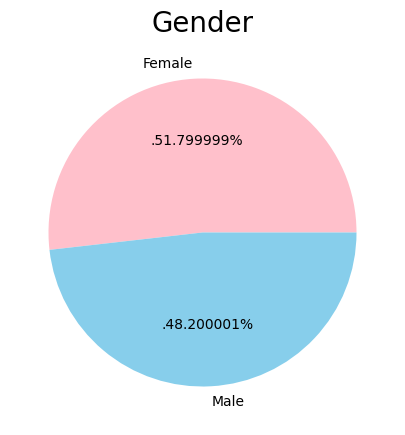

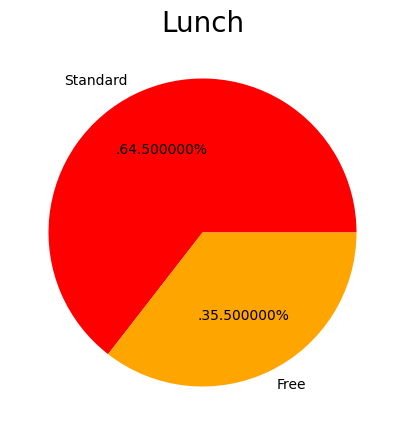

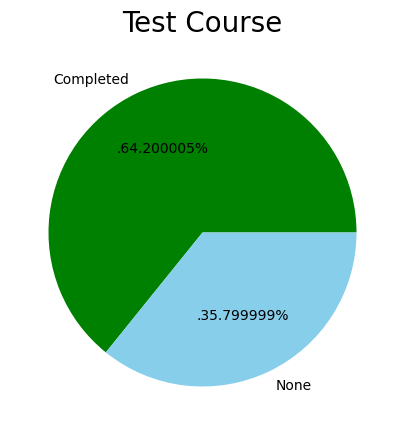

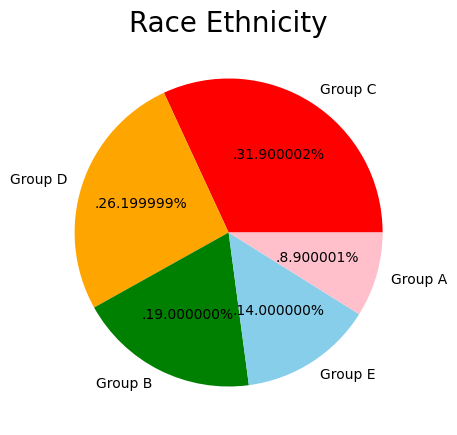

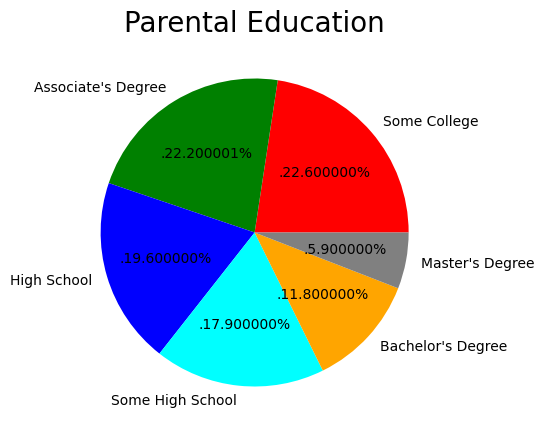

In [29]:
plt.subplots(figsize=(10,5))
size = df['gender'].value_counts()
labels = 'Female','Male'
color = ['pink','skyblue']
plt.pie(size,labels=labels,colors=color,autopct='.%1f%%')
plt.title('Gender', fontsize = 20)


plt.subplots(figsize=(10,5))
size = df['lunch'].value_counts()
labels = 'Standard','Free'
color = ['red','orange']
plt.pie(size,labels=labels,colors=color,autopct='.%1f%%')
plt.title('Lunch', fontsize = 20)


plt.subplots(figsize=(10,5))
size = df['test_preparation_course'].value_counts()
labels = 'Completed','None'
color = ['green','skyblue']
plt.pie(size,labels=labels,colors=color,autopct='.%1f%%')
plt.title('Test Course', fontsize = 20)



plt.subplots(figsize=(10,5))
size = df['race_ethnicity'].value_counts()
labels = 'Group C', 'Group D','Group B','Group E','Group A'
color = ['red','orange','green','skyblue','pink']
plt.pie(size,labels=labels,colors=color,autopct='.%1f%%')
plt.title('Race Ethnicity', fontsize = 20)


plt.subplots(figsize=(10,5))
size = df['parental_level_of_education'].value_counts()
labels = 'Some College', "Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"
color = ['red', 'green', 'blue', 'cyan','orange','grey']
plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Parental Education', fontsize = 20)

plt.grid()
plt.show()



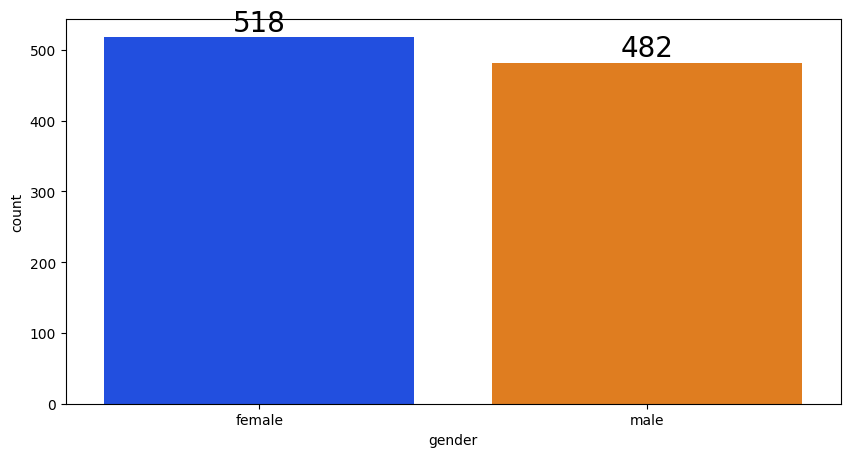

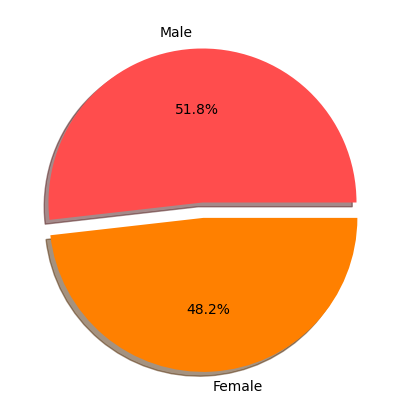

In [ ]:

fig, ax = plt.subplots(figsize=(10,5))

sns.countplot(
    x=df['gender'],
    data=df,
    palette='bright',
    ax=ax
)

for container in ax.containers:
    ax.bar_label(container, color='black', size=20)

plt.show()
    
plt.subplots(figsize=(10,5))
plt.pie(x=df['gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'])
plt.show()

In [42]:
gender_group = df.groupby('gender').mean(numeric_only=True)
gender_group

,math_score,reading_score,writing_score,Total_Marks,Average_Marks
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


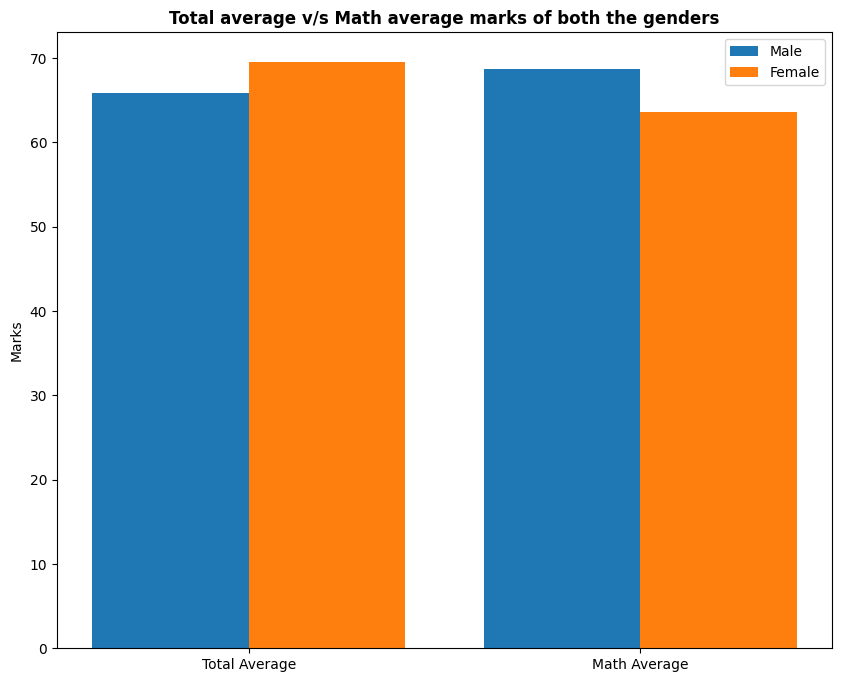

In [48]:
plt.figure(figsize=(10, 8))

X = ['Total Average','Math Average']


female_scores = [gender_group['Average_Marks'][0], gender_group['math_score'][0]]
male_scores = [gender_group['Average_Marks'][1], gender_group['math_score'][1]]

X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.2, male_scores, 0.4, label = 'Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label = 'Female')
  
plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total average v/s Math average marks of both the genders", fontweight='bold')
plt.legend()
plt.show()

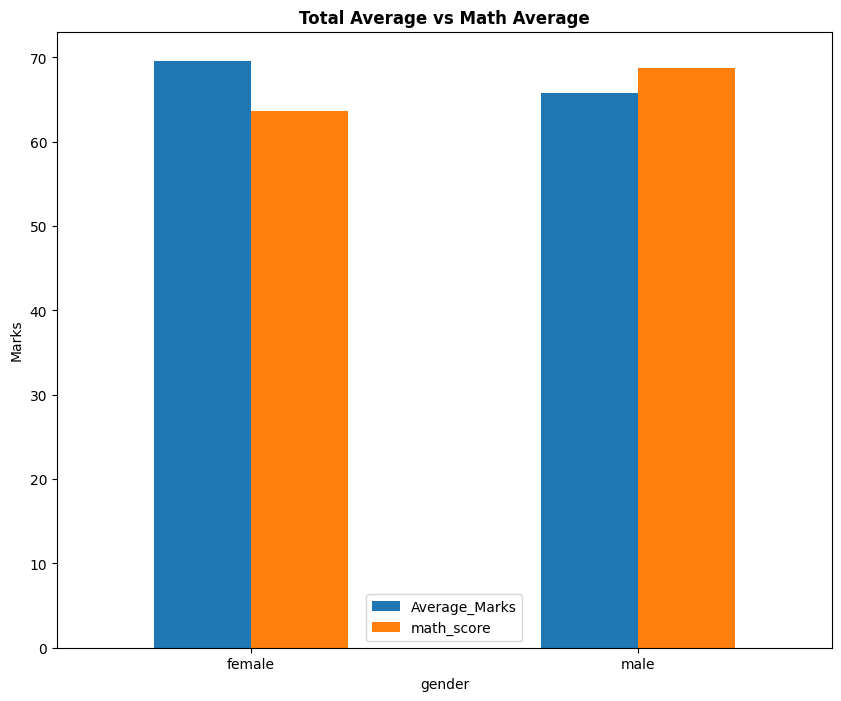

In [46]:
gender_group[['Average_Marks', 'math_score']].plot(
    kind='bar',
    figsize=(10,8)
)

plt.ylabel("Marks")
plt.title("Total Average vs Math Average", fontweight='bold')
plt.xticks(rotation=0)
plt.show()

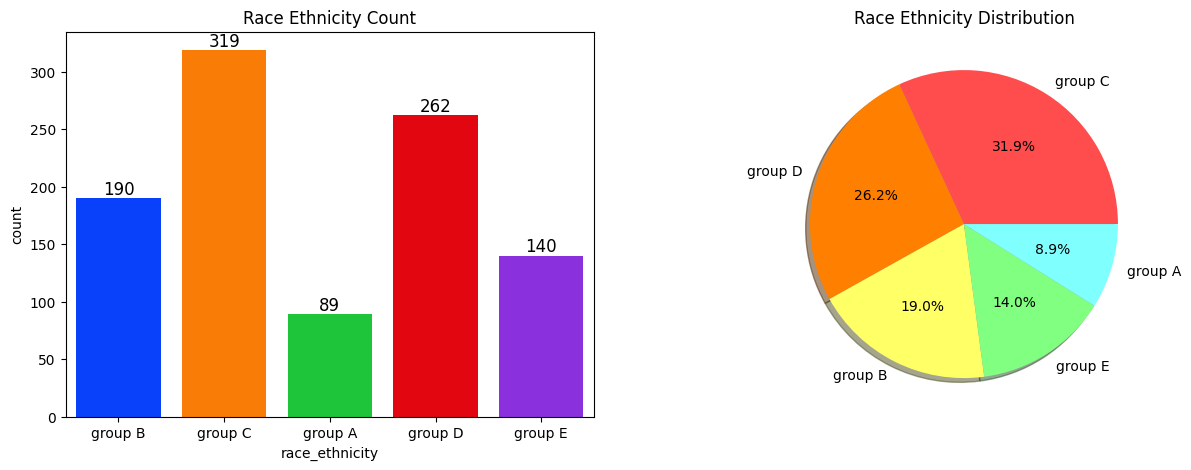

In [52]:
fig, ax = plt.subplots(1, 2, figsize=(15,5))

# Countplot
sns.countplot(
    x=df['race_ethnicity'],
    data=df,
    palette='bright',
    saturation=0.95,
    ax=ax[0]
)

for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=12)

ax[0].set_title("Race Ethnicity Count")

# Pie chart
ax[1].pie(
    x=df['race_ethnicity'].value_counts(),
    labels=df['race_ethnicity'].value_counts().index,
    shadow=True,
    colors=['#ff4d4d','#ff8000','#ffff66','#80ff80','#80ffff'],
    autopct='%1.1f%%'
)

ax[1].set_title("Race Ethnicity Distribution")

plt.show()

In [55]:
Gd=df.groupby('race_ethnicity')
Gd.head()


,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total_Marks,Average_Marks
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333
5,female,group B,associate's degree,standard,none,71,83,78,232,77.333333
6,female,group B,some college,standard,completed,88,95,92,275,91.666667
7,male,group B,some college,free/reduced,none,40,43,39,122,40.666667
8,male,group D,high school,free/reduced,completed,64,64,67,195,65.000000
10,male,group C,associate's degree,standard,none,58,54,52,164,54.666667


In [59]:
group_data = df.groupby('race_ethnicity')[[
    'math_score',
    'reading_score',
    'writing_score'
]].mean()

group_data

,math_score,reading_score,writing_score
race_ethnicity,,,
group A,61.629213,64.674157,62.674157
group B,63.452632,67.352632,65.600000
group C,64.463950,69.103448,67.827586
group D,67.362595,70.030534,70.145038
group E,73.821429,73.028571,71.407143


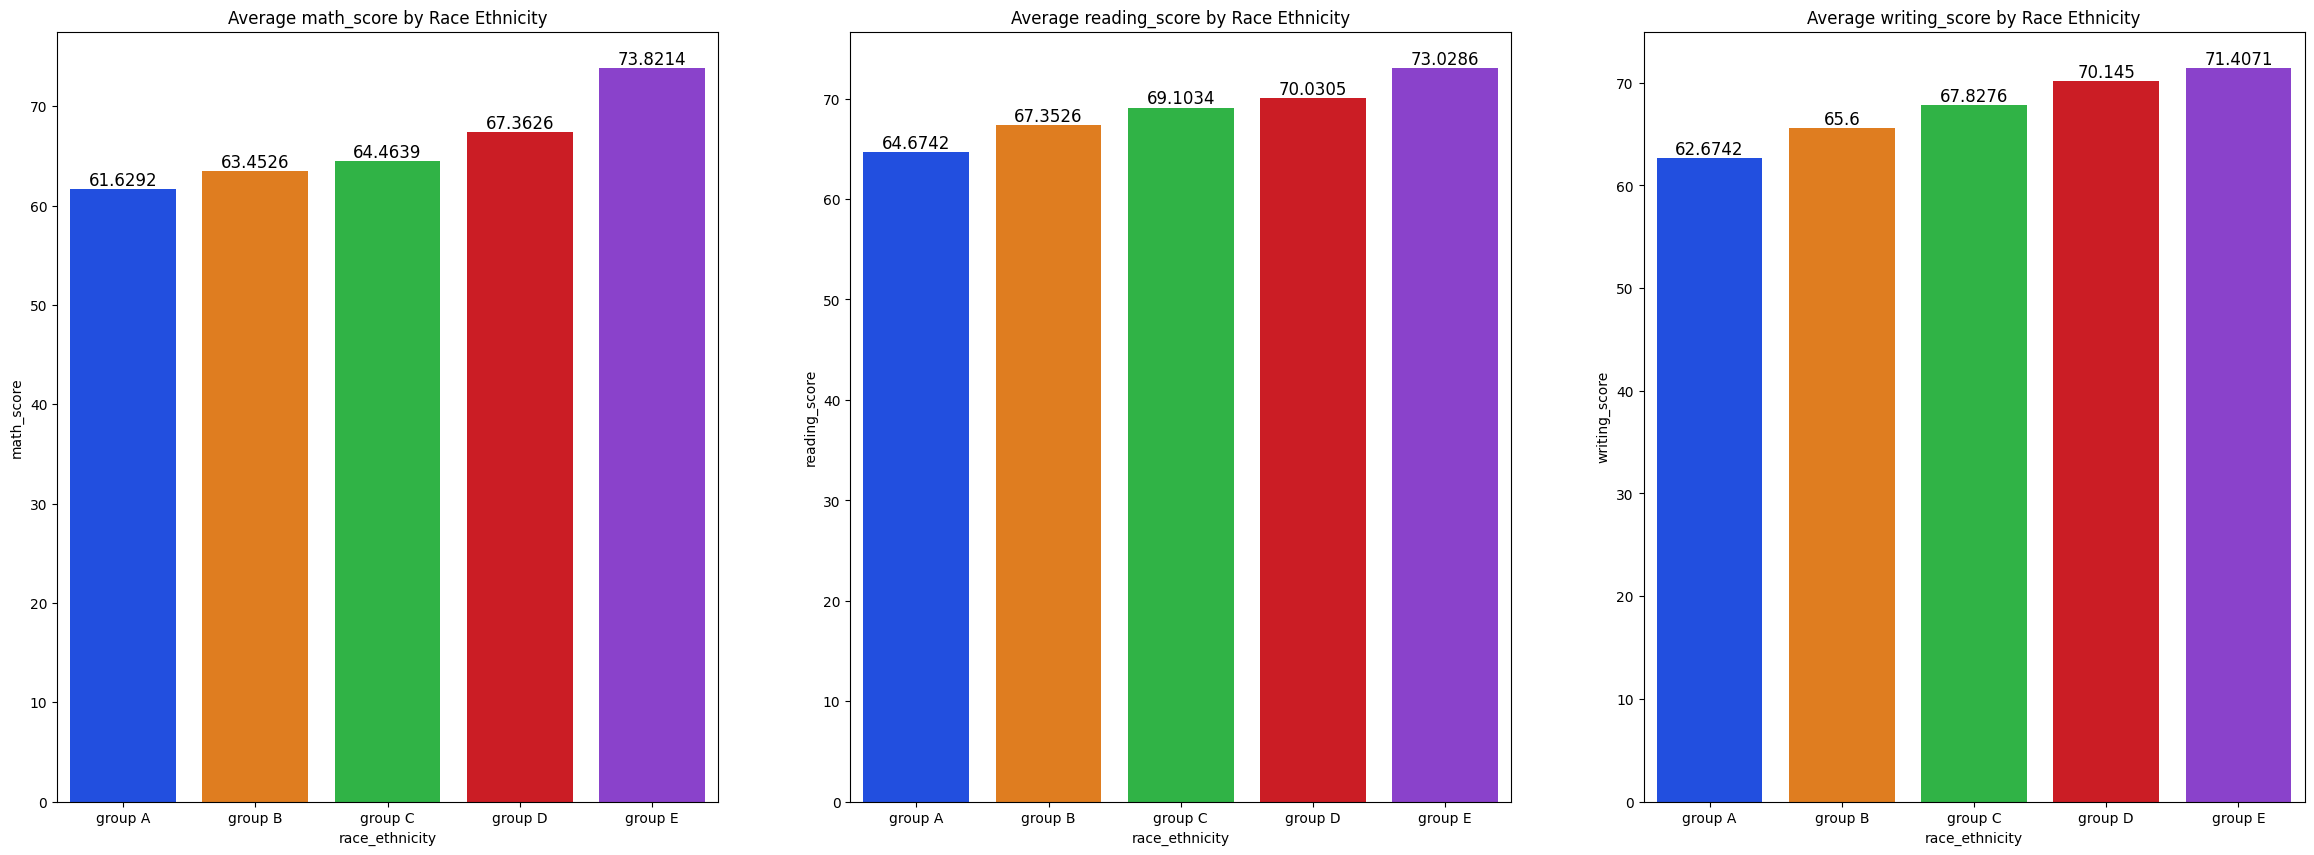

In [64]:
fig , ax = plt.subplots(1,3,figsize=(29,10))

for i,columns in enumerate(group_data.columns):
    sns.barplot(x=group_data.index,y=group_data[columns],ax=ax[i],palette='bright')
    ax[i].set_title(f"Average {columns} by Race Ethnicity")

    for container in ax[i].containers:
        ax[i].bar_label(container,color='black',size=12)

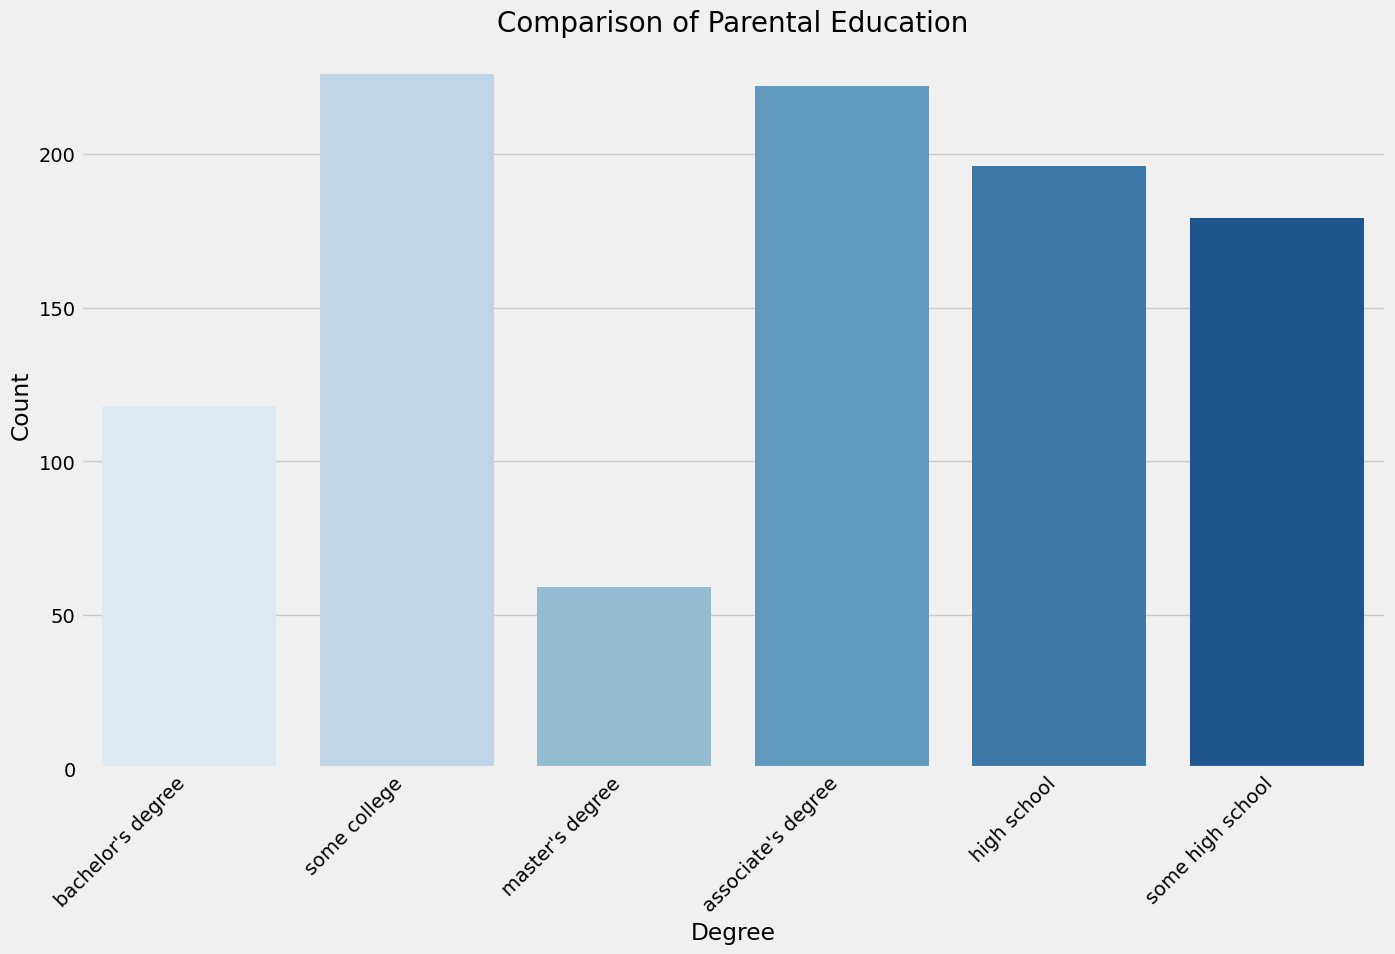

In [74]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')

sns.countplot(
    x='parental_level_of_education',
    data=df,
    palette='Blues'
)

plt.title('Comparison of Parental Education', fontsize=20)
plt.xlabel('Degree')
plt.ylabel('Count')

plt.xticks(rotation=45, ha='right')

plt.show()

In [77]:
df.groupby('parental_level_of_education').agg('mean', numeric_only=True)

,math_score,reading_score,writing_score,Total_Marks,Average_Marks
parental_level_of_education,,,,,
associate's degree,67.882883,70.927928,69.896396,208.707207,69.569069
bachelor's degree,69.389831,73.000000,73.381356,215.771186,71.923729
high school,62.137755,64.704082,62.448980,189.290816,63.096939
master's degree,69.745763,75.372881,75.677966,220.796610,73.598870
some college,67.128319,69.460177,68.840708,205.429204,68.476401
some high school,63.497207,66.938547,64.888268,195.324022,65.108007


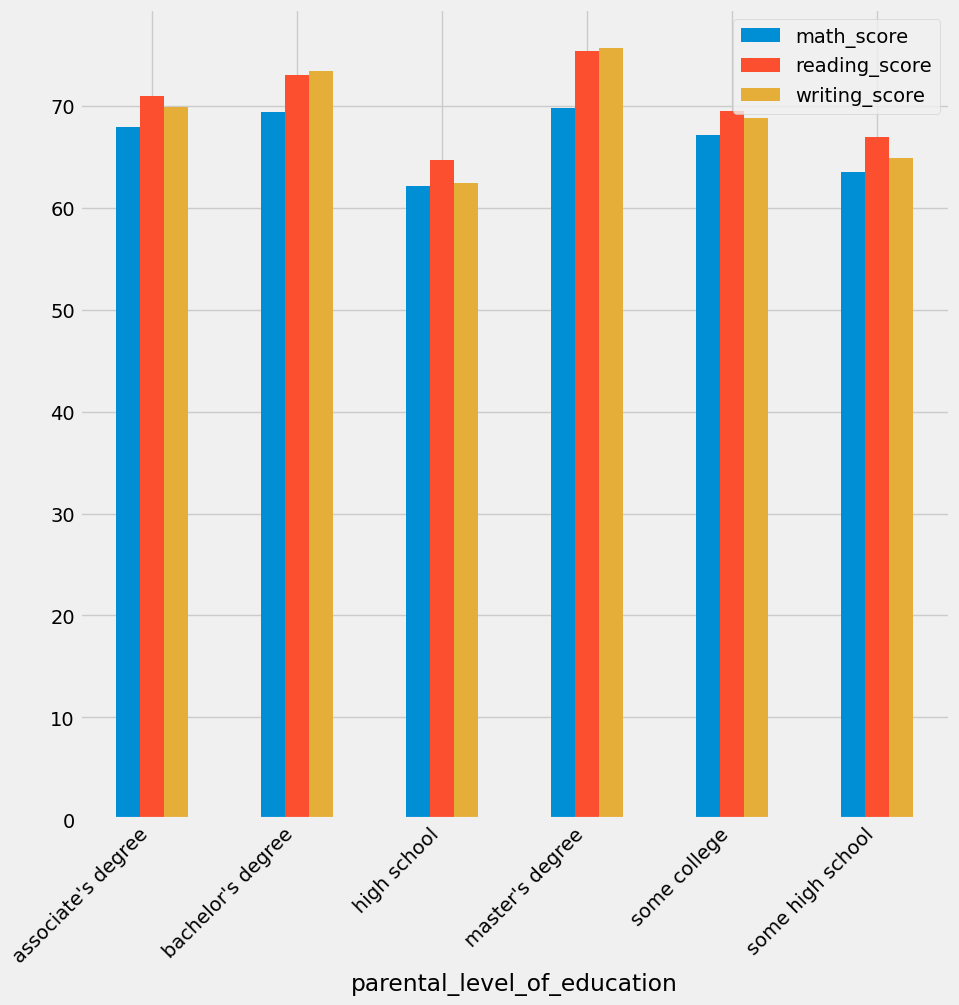

In [87]:
(
    df.groupby('parental_level_of_education')
      .mean(numeric_only=True)
      .drop(['Average_Marks','Total_Marks'], axis=1)
      .plot(kind='bar', figsize=(10,10))
)

plt.xticks(rotation=45, ha='right')
plt.show()

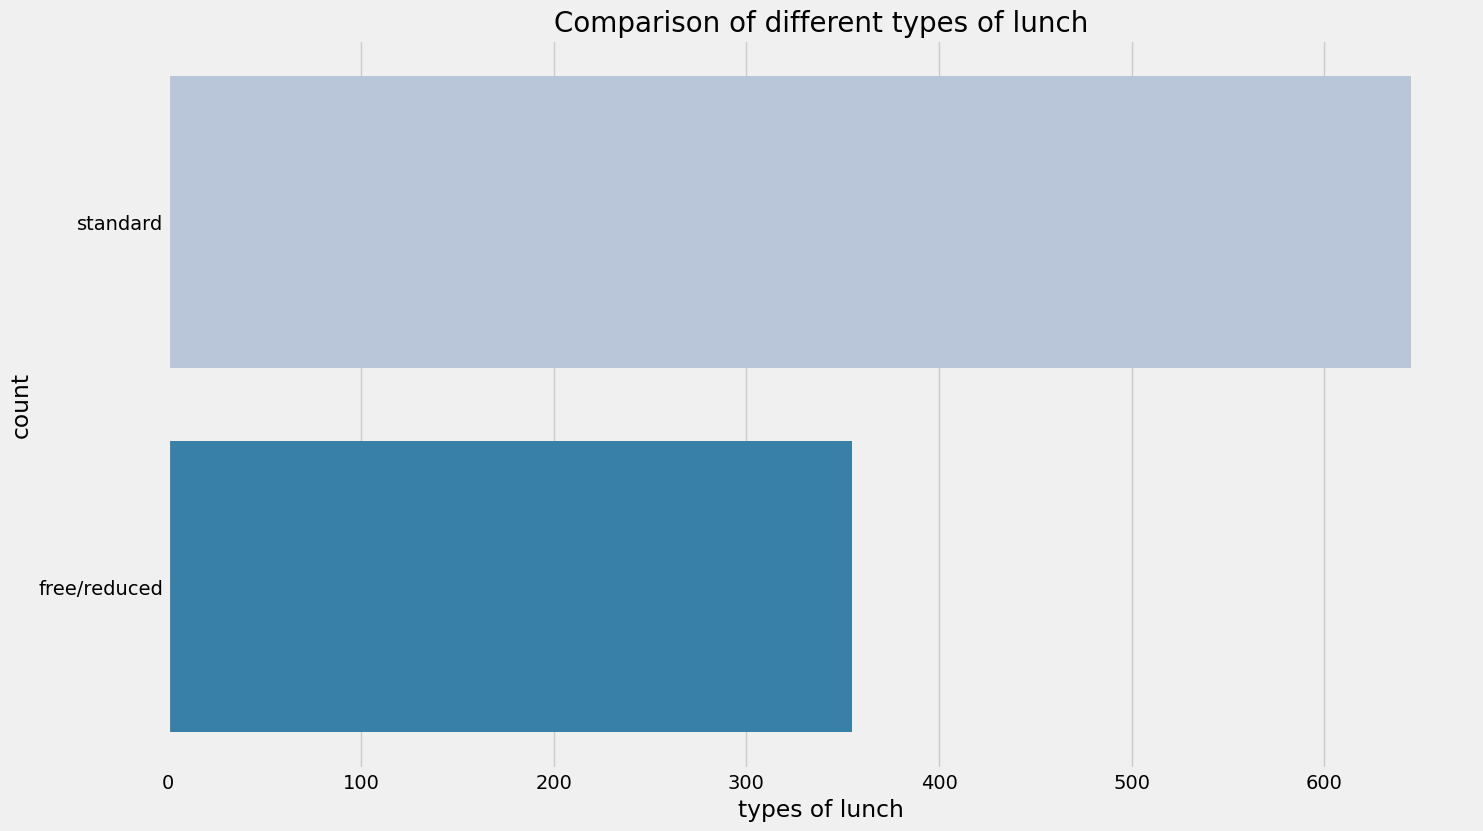

In [88]:

sns.countplot(df['lunch'], palette = 'PuBu')
plt.title('Comparison of different types of lunch', fontweight = 30, fontsize = 20)
plt.xlabel('types of lunch')
plt.ylabel('count')
plt.show()

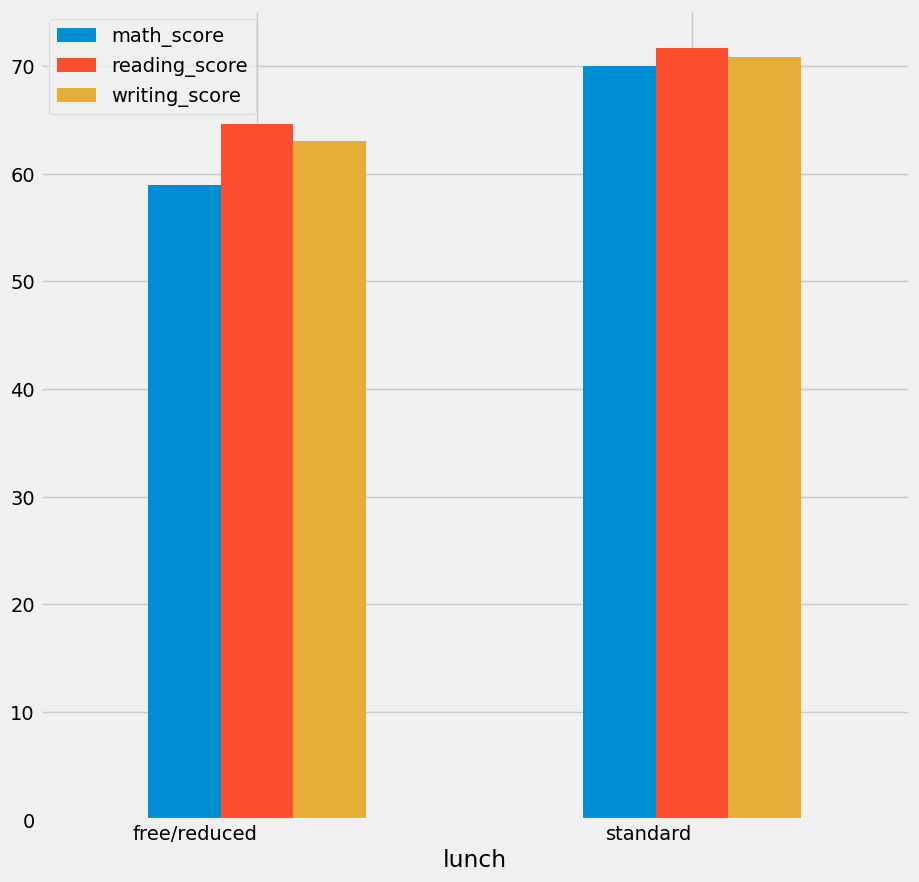

In [94]:
(
    df.groupby('lunch')
      .mean(numeric_only=True)
      .drop(['Average_Marks','Total_Marks'], axis=1)
      .plot(kind='bar', figsize=(10,10))
)

plt.xticks( rotation=0,ha='right')
plt.show()

<Axes: xlabel='lunch', ylabel='writing_score'>

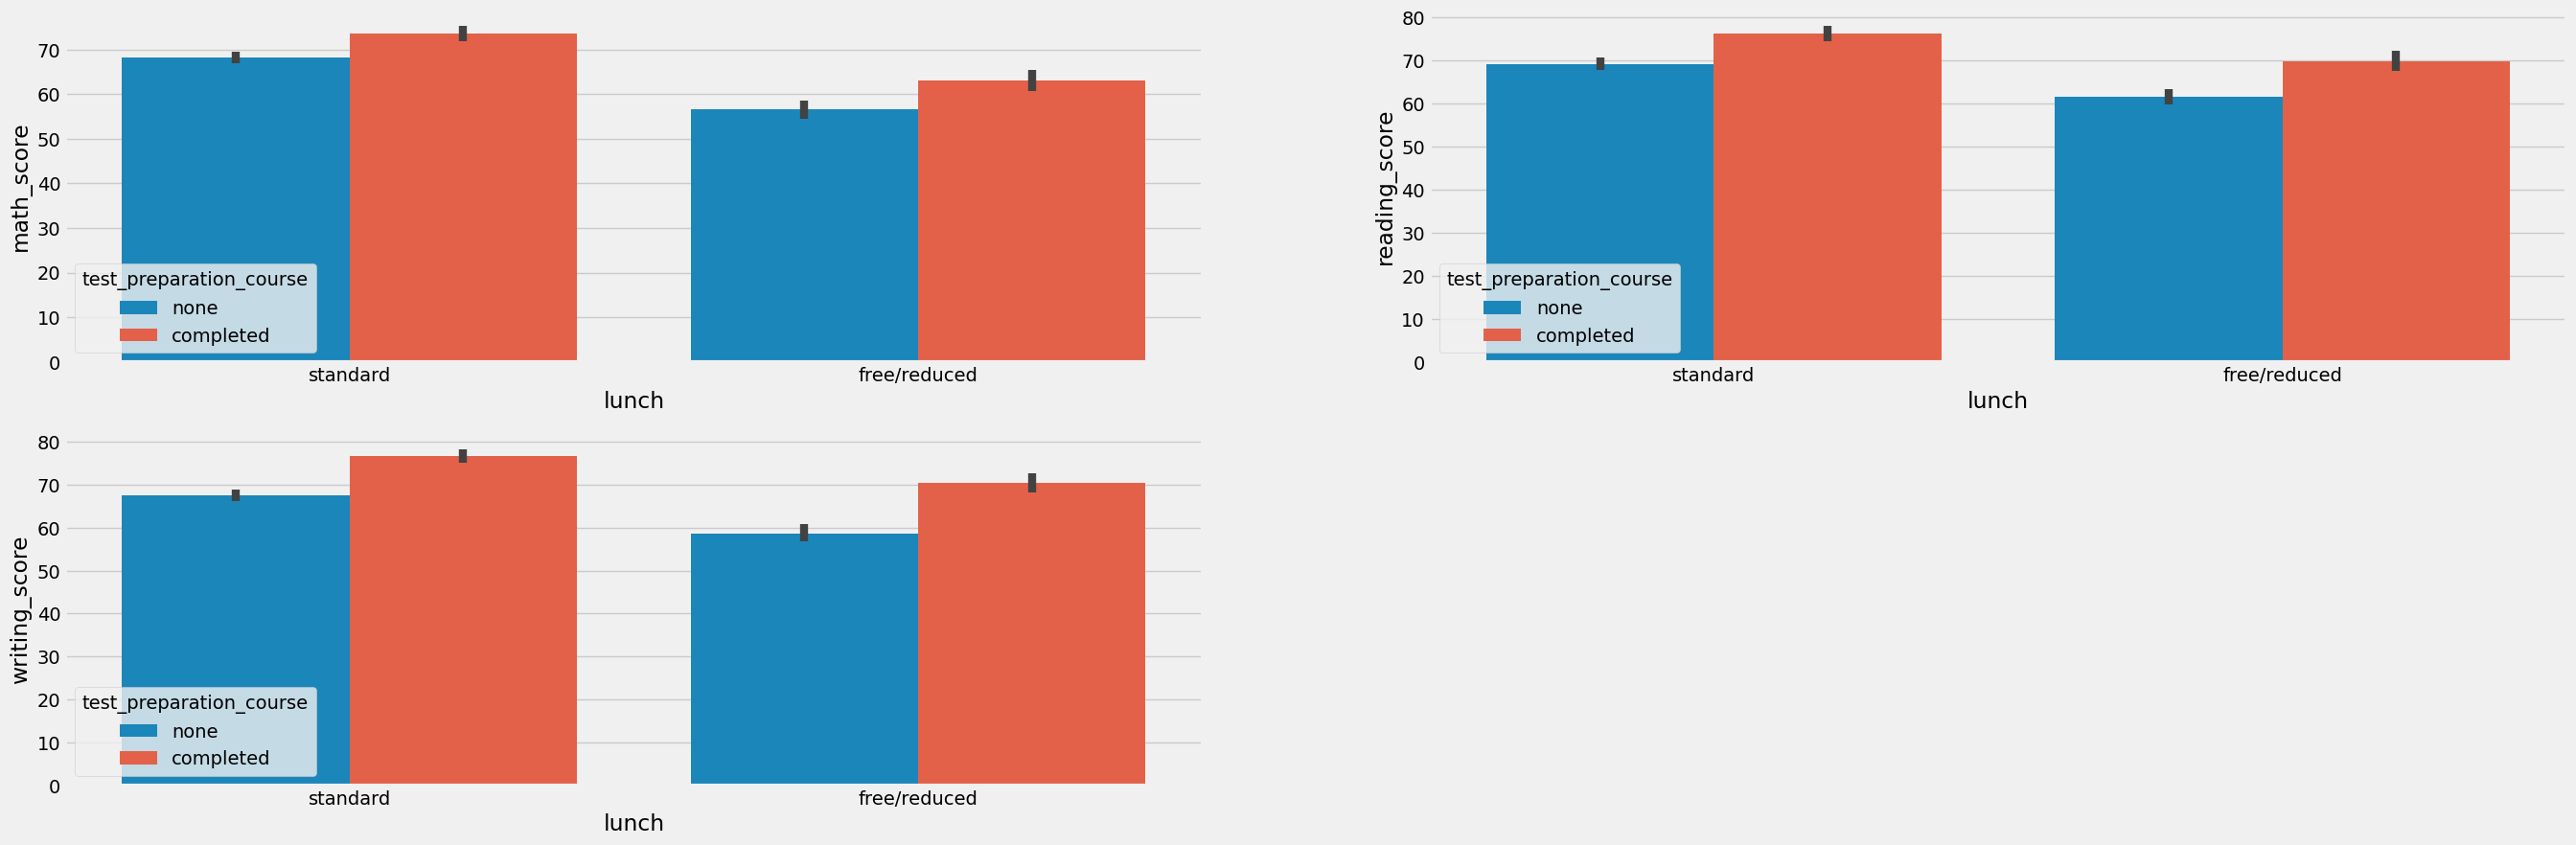

In [97]:
plt.figure(figsize=(30,10))
plt.subplot(2,2,1)
sns.barplot (x=df['lunch'], y=df['math_score'], hue=df['test_preparation_course'])
plt.subplot(2,2,2)
sns.barplot (x=df['lunch'], y=df['reading_score'], hue=df['test_preparation_course'])
plt.subplot(2,2,3)
sns.barplot (x=df['lunch'], y=df['writing_score'], hue=df['test_preparation_course'])

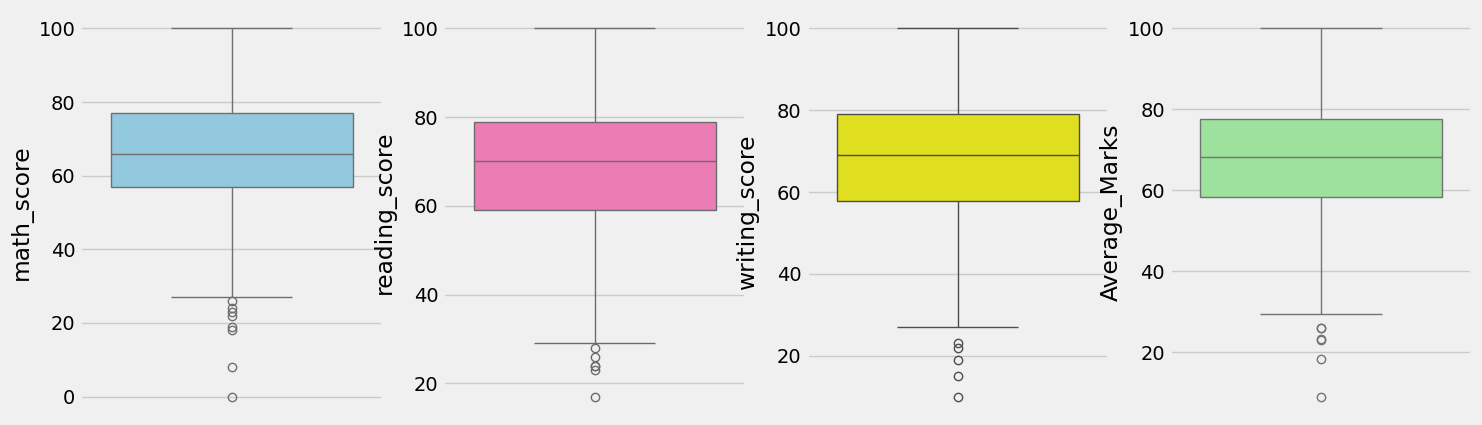

In [100]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math_score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading_score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing_score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['Average_Marks'],color='lightgreen')
plt.show()

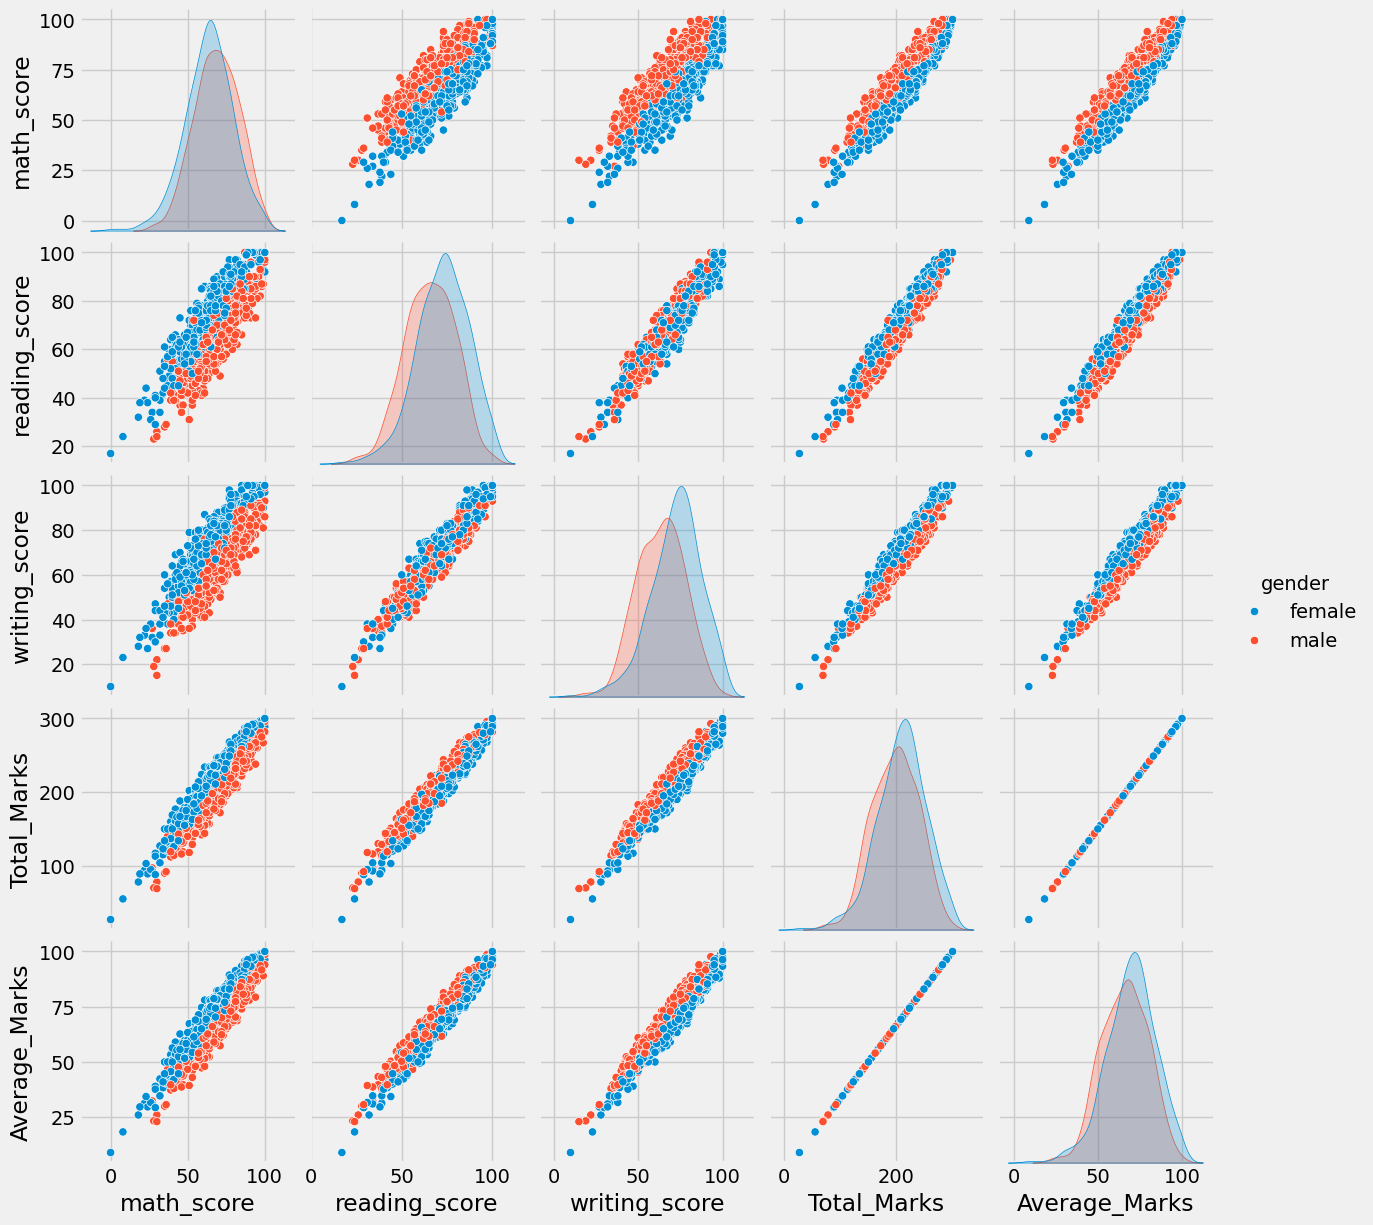

In [101]:
sns.pairplot(df,hue = 'gender')
plt.show()